In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

In [4]:
n, p, size = 1, 0.65, 100
np.random.binomial(n, p, size)

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1])

In [5]:
n = 20
k = 20
ps = np.linspace(0.0001, 0.999, 100)
L_p = ps**k * (1-ps)**(n-k)
l_p = k*np.log(ps) + (n-k)*np.log(1-ps)
ml_p = -l_p

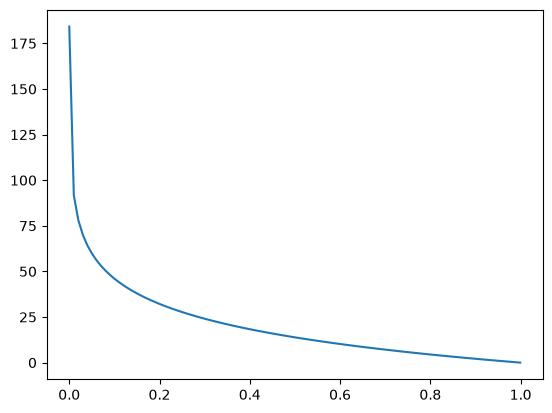

In [6]:
plt.plot(ps, ml_p)

In [7]:

for k in range(0,10):    
    L_p = ps**k * (1-ps)**()

ValueError: operands could not be broadcast together with shapes (100,) (0,) 

np.float64(4.5397868702434395e-05)

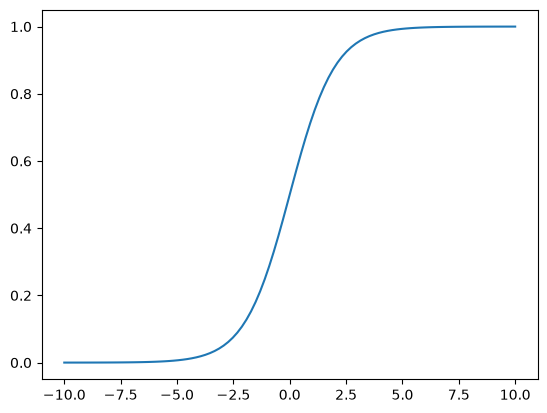

In [8]:
x = np.linspace(-10, 10, 100)
plt.plot(x, expit(x))
min(expit(x))

In [9]:
n = 10
x = np.random.uniform(-1, 1, n)
t_theta = [3.2, 3.14] # truth theta
z = t_theta[1]*x + t_theta[0]
t_probas = expit(z)
y = np.random.binomial(1, t_probas, size=n)
x

array([ 0.04836117,  0.40734234, -0.81874192,  0.11601175, -0.31949422,
        0.4891813 ,  0.00687428,  0.76143182,  0.83201005,  0.87117507])

In [10]:
Z = lambda x: t_theta[0] + t_theta[1]*x

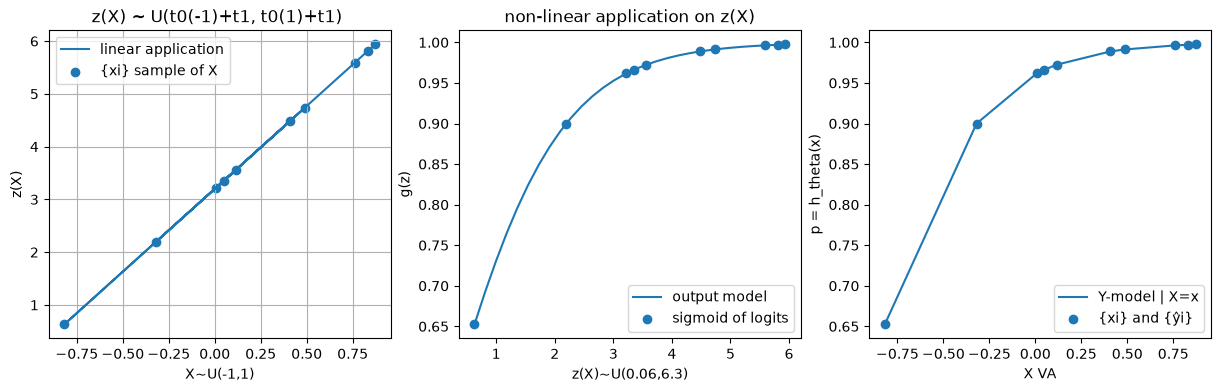

In [11]:
fig = plt.figure(figsize=(15,4))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.set_title(f"z(X) ~ U(t0(-1)+t1, t0(1)+t1) ")
ax1.plot(x, z, label="linear application"); ax1.grid(); ax1.set_xlabel("X~U(-1,1)"); ax1.set_ylabel(f"z(X)"); 
ax1.scatter(x,z, label="{xi} sample of X"); ax1.legend()


sigmoid_x = np.linspace(min(z),max(z),30)
ax2.plot(sigmoid_x, expit(sigmoid_x), label="output model"); ax2.set_title("non-linear application on z(X)"); ax2.set_xlabel(f"z(X)~U({Z(-1):0.1},{Z(1):0.2})"); ax2.set_ylabel("g(z)")
ax2.scatter(z, t_probas, label="sigmoid of logits"); ax2.legend()

_x = x.copy(); _t_probas = t_probas.copy()
_x.sort(); _t_probas.sort()
ax3.plot(_x, _t_probas, label="Y-model | X=x"); ax3.set_xlabel("X VA"); ax3.set_ylabel("p = h_theta(x)")
ax3.scatter(x, t_probas, label="{xi} and {ŷi}"); ax3.legend()

In [12]:
# machine learning problem statement
# suppose we have x dataset d=1 features x = [] that aparently are in -1, 1 and uniform wow
# also we have y that are 0 or 1
# we know that exist a correlation between this
# we say that random variable Y | X=x ~ Be as an supposition
# using machine learning theory and statics inference theory we suppose that
# Y|X=x;Theta ~ Be(h_theta(x)) so random variable will distribute bernoulli with parameter p that depends
# on theta and the x value that is VA that we suppossed previously Y is dependent of
# we say that h_theta(x) = g(z) = 1 / (1 + exp(-Theta.T @ x)), g def sigmoid, z def linear application

In [26]:
# surface visualization
t0_plane = np.linspace(t_theta[0]-3, t_theta[0]+3, 50)
t1_plane = np.linspace(t_theta[1]-3, t_theta[1]+3, 50)
T0, T1 = np.meshgrid(t0_plane, t1_plane)

In [31]:
def likely_hood(x, y, theta):
    X = np.column_stack([np.ones_like(x), x])
    h_theta = expit(X @ theta)
    prob_of_yvec = h_theta**y * (1-h_theta)**(1-y)
    return np.prod(prob_of_yvec)
likely_hood(x, y, np.array([0.2,0.14]))

np.float64(0.002494728041161328)

In [28]:
L = np.zeros_like(T0)
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        L[i,j] = likely_hood(x,y, np.array([T0[i,j], T1[i,j]]))

np.float64(0.00249472804116133)

In [33]:
def log_likelyhood(x, y, theta):
    X = np.column_stack([np.ones_like(x), x])
    h_theta = expit(X @ theta)
    probas = y * np.log(h_theta) + (1-y) * np.log(1-h_theta)
    return np.sum(probas)
log_likelyhood(x, y, t_theta)

np.float64(-2.860274680377916)

In [53]:
l = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T1.shape[1]):
        l[i,j] = log_likelyhood(x, y, np.array([T0[i,j], T1[i,j]]))

In [54]:
print(l[0,0])
print(l)

-5.9935755572583
[[-5.99357556 -5.59322335 -5.22912912 ... -5.93547843 -6.05503725
  -6.17492845]
 [-5.84202498 -5.45013902 -5.09421125 ... -5.89579598 -6.01541932
  -6.13536763]
 [-5.70219504 -5.31852331 -4.97043713 ... -5.85622781 -5.97590256
  -6.09589636]
 ...
 [-6.34866473 -6.10108392 -5.86749362 ... -4.37502644 -4.46625449
  -4.56037818]
 [-6.4274153  -6.18046962 -5.94732665 ... -4.36196458 -4.45086933
  -4.5428208 ]
 [-6.50697243 -6.26063675 -6.02792292 ... -4.35088076 -4.43734415
  -4.52700305]]


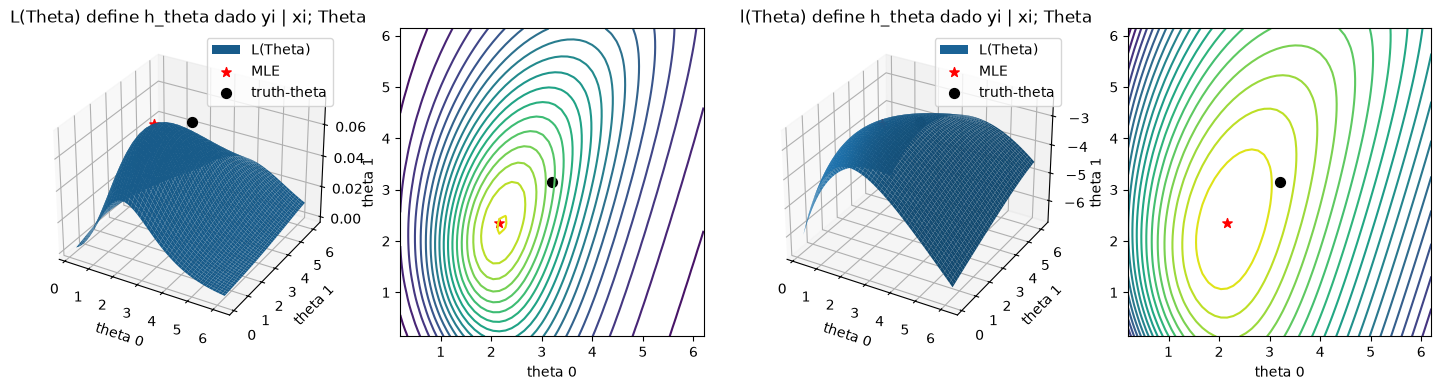

In [110]:
fig = plt.figure(figsize=(18,4))
i = 1
for Z in [L,l]:
    ax1 = fig.add_subplot(1,4,i, projection="3d")
    ax2 = fig.add_subplot(1,4,i+1)

    ax1.set_title(f"{"L" if i==1 else "l"}(Theta) define h_theta dado yi | xi; Theta")
    ax1.plot_surface(T0, T1, Z, antialiased=True, label="L(Theta)"); 
    
    
    ax2.contour(T0, T1, Z, levels=20, label="contorno de superficie de verosimilitud")

    idx_max = np.unravel_index(Z.argmax(), Z.shape)
    ax1.scatter(T0[idx_max], T1[idx_max], Z[idx_max], c="red", s=50, marker='*', label="MLE") # max likelyhood estimation
    ax2.scatter(T0[idx_max], T1[idx_max], c="red", s=50, marker="*")
    ax1.scatter(t_theta[0], t_theta[1], Z[idx_max], c="black", s=50, marker='o', label="truth-theta")
    ax2.scatter(t_theta[0], t_theta[1], c="black", s=50, marker="o")

    ax1.set_xlabel("theta 0"); ax1.set_ylabel("theta 1"); ax1.legend()
    ax2.set_xlabel("theta 0"); ax2.set_ylabel("theta 1"); 
    i +=2

array([[0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5]])